## Setup and Data Loading (Tabular Data)

We will load the California Housing dataset from the `/content/sample_data/` directory, as it's typically available in Colab environments and avoids external download issues. We will load both the training and test CSVs for a more complete dataset.

In [1]:
import pandas as pd
import numpy as np

# Load California Housing data from local CSV files
try:
    df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
    df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

    # Combine train and test for initial processing, then split later.
    df_tabular = pd.concat([df_train, df_test], ignore_index=True)

    # The target variable is 'median_house_value' in these CSVs.
    # We'll rename it to 'MedHouseVal' for consistency with previous steps.
    if 'median_house_value' in df_tabular.columns:
        df_tabular['MedHouseVal'] = df_tabular['median_house_value']
    else:
        print("Error: 'median_house_value' column not found in the loaded CSVs.")
        # Fallback to assigning the last column as target if specific name is missing
        df_tabular['MedHouseVal'] = df_tabular.iloc[:, -1]

    print("Tabular Housing Data Loaded Successfully from local CSVs!")
    print("\nFirst 5 rows of the tabular dataset:")
    display(df_tabular.head())

    print("\nInformation about the tabular dataset:")
    df_tabular.info()

except FileNotFoundError:
    print("Error: California Housing CSV files not found in /content/sample_data.")
    print("Please ensure 'california_housing_train.csv' and 'california_housing_test.csv' exist or adjust the paths.")
except Exception as e:
    print(f"An error occurred while loading the CSVs: {e}")

Tabular Housing Data Loaded Successfully from local CSVs!

First 5 rows of the tabular dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,MedHouseVal
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,65500.0



Information about the tabular dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20000 non-null  float64
 1   latitude            20000 non-null  float64
 2   housing_median_age  20000 non-null  float64
 3   total_rooms         20000 non-null  float64
 4   total_bedrooms      20000 non-null  float64
 5   population          20000 non-null  float64
 6   households          20000 non-null  float64
 7   median_income       20000 non-null  float64
 8   median_house_value  20000 non-null  float64
 9   MedHouseVal         20000 non-null  float64
dtypes: float64(10)
memory usage: 1.5 MB


## Image Data Loading and Preprocessing

To fulfill the multimodal aspect of this task, we need to acquire and preprocess an image dataset corresponding to the housing data. Since a specific image dataset was not provided
This code is designed to generate dummy image features if a real image directory is not specified, allowing us to proceed with the multimodal model development.

In [4]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# --- Placeholder for Image Data Loading ---
# You will need to replace this section with your actual image data loading logic.
# This example assumes you have an 'images' directory containing house images
# and a mapping from image filenames to house IDs in your tabular data.

image_dir = 'path/to/your/house_images/' # **UPDATE THIS PATH** to your image directory

# Get the number of rows in the tabular data, as image features must align with this.
num_tabular_rows = len(df_tabular)
image_input_shape = (128, 128, 3) # Define a consistent shape for dummy images

if not os.path.exists(image_dir):
    print(f"Warning: Image directory '{image_dir}' not found. Creating dummy image data for demonstration.")
    dummy_image_features = np.random.rand(num_tabular_rows, *image_input_shape)
    print(f"Created dummy image features with shape: {dummy_image_features.shape}")
    image_data = dummy_image_features # Use dummy data for further processing

else:
    # Example of loading actual images (you'd need to adapt this to your data structure)
    image_filenames = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Limit for demonstration if there are too many images
    num_images_to_load = min(len(image_filenames), num_tabular_rows) # Load up to the number of tabular rows
    print(f"Found {len(image_filenames)} images. Loading {num_images_to_load} for processing.")

    loaded_images = []
    for i, fname in enumerate(image_filenames[:num_images_to_load]):
        try:
            img_path = os.path.join(image_dir, fname)
            img = load_img(img_path, target_size=(image_input_shape[0], image_input_shape[1])) # Resize images to a common size
            img_array = img_to_array(img)
            loaded_images.append(img_array)
        except Exception as e:
            print(f"Could not load image {fname}: {e}")

    if loaded_images:
        image_data = np.array(loaded_images) / 255.0 # Normalize pixel values to [0, 1]
        print(f"Loaded and preprocessed image data with shape: {image_data.shape}")
    else:
        print("No images were loaded from the provided directory. Falling back to dummy data.")
        image_data = np.random.rand(num_tabular_rows, *image_input_shape) # Fallback to dummy if no images loaded

# Assuming image_data contains preprocessed images, the next step would be feature extraction via CNN.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 761.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 154.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 104.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Created dummy image features with shape: (20000, 128, 128, 3)


## CNN Feature Extraction from Images

We will define a simple Convolutional Neural Network (CNN) to extract features from the image data. This CNN will process the `image_data` (which currently holds our dummy features) to generate a fixed-size feature vector for each 'image'. This step is crucial for transforming raw image pixels into a more abstract and useful representation for the downstream regression task.

In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
import tensorflow as tf # Import tensorflow to catch specific errors
import numpy as np # Needed for dummy data creation

# Define the input shape for the CNN (matching the dummy_image_features or actual image size)
image_input_shape = (128, 128, 3)

# --- Ensure image_data is defined ---
# This logic is copied from cell 383b5c50 to make this cell self-sufficient.
# In a real scenario, you'd load actual images here.
if 'image_data' not in globals() or image_data is None:
    print("Warning: 'image_data' not found or is None. Creating dummy image data for demonstration.")
    # Assuming df_tabular is already loaded from previous cells for num_tabular_rows
    try:
        num_tabular_rows = len(df_tabular) # Needs df_tabular to be defined
    except NameError:
        # Fallback if df_tabular isn't defined either (shouldn't happen with self-sufficient tabular cell)
        print("Error: df_tabular is not defined. Cannot determine number of rows for dummy image data.")
        num_tabular_rows = 20000 # Default to 20000 as per problem description
    image_data = np.random.rand(num_tabular_rows, *image_input_shape).astype(np.float32)
    print(f"Created dummy image data with shape: {image_data.shape}")


# Define a simple CNN for feature extraction
input_img = Input(shape=image_input_shape, name='image_input')
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Flatten()(x) # Flatten the output to create a feature vector

cnn_feature_extractor = Model(inputs=input_img, outputs=x, name='cnn_feature_extractor')

print("CNN Feature Extractor Model Summary:")
cnn_feature_extractor.summary()

# Extract features using the (dummy) image data
image_features = None # Initialize to None
try:
    # Use batch_size to prevent potential memory issues when processing large image_data
    print("\nExtracting image features from dummy data...")
    image_features = cnn_feature_extractor.predict(image_data, batch_size=32)

    print(f"\nExtracted image features shape: {image_features.shape}")
    print("First 5 extracted image features (flattened, sample):")
    print(image_features[:5])
except tf.errors.ResourceExhaustedError as e:
    print(f"Error: GPU memory exhausted during feature extraction. Try reducing batch_size or image_data size: {e}")
except Exception as e:
    print(f"An unexpected error occurred during feature extraction: {e}")
finally:
    if image_features is None:
        print("\nImage feature extraction failed or returned no features.")
    else:
        print("\nImage feature extraction completed successfully.")


CNN Feature Extractor Model Summary:


Model: "cnn_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)


Extracting image features from dummy data...
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 100ms/step

Extracted image features shape: (20000, 32768)
First 5 extracted image features (flattened, sample):
[[0.18185446 0.02365728 0.26979715 ... 0.1340238  0.         0.        ]
 [0.19392203 0.00118897 0.20898977 ... 0.11835601 0.         0.        ]
 [0.17853601 0.00423878 0.18270741 ... 0.11845552 0.         0.        ]
 [0.19088349 0.01294132 0.23422532 ... 0.13576591 0.         0.        ]
 [0.21594974 0.01461714 0.21354751 ... 0.11335782 0.         0.        ]]

Image feature extraction completed successfully.


## Tabular Data Preprocessing

Before combining with image features and training a multimodal model, the tabular data needs standard preprocessing steps. This includes:

1.  **Separating Features and Target**: Differentiating `X_tabular` (input features) from `y_tabular` (the target variable, `MedHouseVal`).
2.  **Handling Categorical Features**: Although the California Housing dataset primarily contains numerical features, in a real-world scenario, you might encounter categorical variables (e.g., 'ocean_proximity'). For this dataset, we will primarily focus on numerical scaling.
3.  **Scaling Numerical Features**: Standardizing numerical features to have zero mean and unit variance. This is crucial for models like neural networks, which can be sensitive to feature scales.

We'll use `StandardScaler` for numerical feature scaling. We will also drop the original `median_house_value` column if it exists, as `MedHouseVal` is our consistent target.

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Re-load df_tabular to ensure it's defined in case previous cell was not run ---
# This section is copied from cell 21b11d9f to make this cell self-sufficient.
try:
    df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
    df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

    df_tabular = pd.concat([df_train, df_test], ignore_index=True)

    if 'median_house_value' in df_tabular.columns:
        df_tabular['MedHouseVal'] = df_tabular['median_house_value']
    else:
        print("Error: 'median_house_value' column not found in the loaded CSVs. Falling back to last column.")
        df_tabular['MedHouseVal'] = df_tabular.iloc[:, -1]

except FileNotFoundError:
    print("Error: California Housing CSV files not found. Cannot proceed with tabular data preprocessing.")
    # Exit or handle error gracefully if data cannot be loaded
    raise
except Exception as e:
    print(f"An error occurred during df_tabular loading: {e}")
    raise
# --- End of df_tabular re-load ---


# Separate features (X) and target (y) from the tabular data
X_tabular = df_tabular.drop(columns=['MedHouseVal', 'median_house_value'], errors='ignore')
y_tabular = df_tabular['MedHouseVal']

print(f"Original X_tabular shape: {X_tabular.shape}")
print(f"Original y_tabular shape: {y_tabular.shape}")

# Identify numerical and categorical columns
numerical_cols = X_tabular.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_tabular.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Create a preprocessing pipeline for numerical and (if any) categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols) # handle_unknown='ignore' for unseen categories in test set
    ])

# Fit and transform the tabular features
X_tabular_processed = preprocessor.fit_transform(X_tabular)

print(f"\nProcessed X_tabular shape: {X_tabular_processed.shape}")
print("First 5 rows of processed tabular features (sample):\n", X_tabular_processed[:5])


Original X_tabular shape: (20000, 8)
Original y_tabular shape: (20000,)
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical columns: []

Processed X_tabular shape: (20000, 8)
First 5 rows of processed tabular features (sample):
 [[ 2.62341796 -0.67260797 -1.0831221   1.36700025  1.77121186 -0.36299762
  -0.07210901 -1.25165577]
 [ 2.54356006 -0.57429739 -0.76520547  2.30346909  3.24046942 -0.26220367
  -0.0956865  -1.07989419]
 [ 2.49863999 -0.90668077 -0.92416378 -0.88089256 -0.86536845 -0.96599304
  -1.00211012 -1.16887974]
 [ 2.49364887 -0.93008805 -1.16260126 -0.52202006 -0.47784583 -0.80507637
  -0.71656049 -0.35806404]
 [ 2.49364887 -0.96285824 -0.68572631 -0.54361674 -0.50399766 -0.70870321
  -0.62225051 -1.02464001]]


## Feature Fusion: Combining Image and Tabular Data

Now that we have extracted features from the images (`image_features`) and preprocessed the tabular data (`X_tabular_processed`), the next step is to combine these two sets of features. This fusion creates a comprehensive dataset that integrates information from both modalities, allowing our multimodal model to leverage all available data for prediction.

We will concatenate `image_features` and `X_tabular_processed` horizontally (along `axis=1`) to form a single feature matrix. It's crucial that the number of samples (rows) in both feature sets is the same, which we have ensured by creating dummy image data that matches the tabular data's row count.

After fusion, we will proceed with splitting the data into training and testing sets.

In [7]:
# Ensure both feature sets exist before attempting to combine
if 'image_features' in globals() and image_features is not None and X_tabular_processed is not None:
    # Ensure the number of samples (rows) match
    if image_features.shape[0] == X_tabular_processed.shape[0]:
        # Concatenate image features and tabular features horizontally
        # Use np.concatenate for combining NumPy arrays
        X_fused = np.concatenate([image_features, X_tabular_processed], axis=1)
        print(f"Successfully fused image and tabular features. Combined shape: {X_fused.shape}")
        print("First 5 rows of fused features (sample):\n", X_fused[:5, :10]) # Displaying first 10 columns for sample
    else:
        print("Error: Mismatch in number of samples between image features and tabular features.")
        print(f"Image features samples: {image_features.shape[0]}, Tabular features samples: {X_tabular_processed.shape[0]}")
        X_fused = None
else:
    print("Error: Image features or processed tabular features are missing. Cannot perform fusion.")
    print("Is image_features defined?", 'image_features' in globals() and image_features is not None)
    print("Is X_tabular_processed defined?", X_tabular_processed is not None)
    X_fused = None

# Also ensure the target variable y is in a numpy array format for consistency
y_fused = y_tabular.values if isinstance(y_tabular, pd.Series) else y_tabular
print(f"Fused target variable shape: {y_fused.shape}")

Successfully fused image and tabular features. Combined shape: (20000, 32776)
First 5 rows of fused features (sample):
 [[0.18185446 0.02365728 0.26979715 0.         0.31123489 0.
  0.01170363 0.02613591 0.         0.        ]
 [0.19392203 0.00118897 0.20898977 0.         0.24030472 0.
  0.00742709 0.02763995 0.         0.        ]
 [0.17853601 0.00423878 0.18270741 0.         0.29896221 0.
  0.01263946 0.02073869 0.         0.        ]
 [0.19088349 0.01294132 0.23422532 0.         0.29022378 0.
  0.         0.01028844 0.         0.        ]
 [0.21594974 0.01461714 0.21354751 0.         0.28959528 0.
  0.05011233 0.01611727 0.         0.        ]]
Fused target variable shape: (20000,)


## Data Splitting

We will now split our fused dataset (`X_fused`) and the corresponding target variable (`y_fused`) into training and testing sets. This is a critical step in machine learning to evaluate the model's performance on unseen data. We'll use `sklearn.model_selection.train_test_split` for this purpose.


In [8]:
from sklearn.model_selection import train_test_split

# Split the fused data into training and testing sets
# Using a 80/20 split, with a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_fused, y_fused, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (16000, 32776)
X_test shape: (4000, 32776)
y_train shape: (16000,)
y_test shape: (4000,)


## Model Training: Multimodal Regression Model

Now we will define and train a simple multimodal regression model using the fused features (`X_fused`). This model will be built using Keras, allowing us to leverage the combined power of image and tabular data for housing price prediction.

We'll use a sequential model with dense layers, which is suitable for handling the flattened feature vector generated from the concatenation of image and tabular features. The model will output a single value (the predicted housing price), making it a regression task.

We will compile the model with an appropriate optimizer (e.g., Adam) and loss function for regression (e.g., Mean Squared Error - MSE). We will also monitor Mean Absolute Error (MAE) during training for easier interpretation of prediction errors.

In [9]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

# Define the multimodal model
# Since X_fused is already a combined feature vector, we can use a simple feed-forward network.

# Get the input dimension from the training data
input_dim = X_train.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # Output layer for regression (single continuous value)
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

print("Multimodal Regression Model Summary:")
model.summary()

# Train the model
print("\nStarting model training...")
history = model.fit(
    X_train, y_train,
    epochs=20, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use a portion of the training data for validation
    verbose=1
)

print("\nModel training completed.")


Multimodal Regression Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     8,390,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,432,129 (32.17 MB)

 Trainable params: 8,432,129 (32.17 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 34s 83ms/step - loss: 20944648192.0000 - mae: 110811.1094 - val_loss: 13027467264.0000 - val_mae: 89479.6172
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 84ms/step - loss: 13240665088.0000 - mae: 90742.1406 - val_loss: 12941767680.0000 - val_mae: 90229.4609
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - loss: 13171328000.0000 - mae: 90634.5000 - val_loss: 12968967168.0000 - val_mae: 88165.7109
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - loss: 13055785984.0000 - mae: 90176.1797 - val_loss: 12818079744.0000 - val_mae: 88114.8281
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - loss: 12921250816.0000 - mae: 89677.9922 - val_loss: 12678684672.0000 - val_mae: 90728.7969
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - loss: 12732052480.0000 - mae: 89019.5625 - val_loss: 12821978112.0000 - val_mae: 93374.2266
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - loss: 12384412672.0000 - ma

## Performance Evaluation

After training our multimodal regression model, it's essential to evaluate its performance on the test set (`X_test`, `y_test`) to understand how well it generalizes to unseen data. We will use two common regression metrics:

1.  **Mean Absolute Error (MAE)**: Measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average over the test sample of the absolute differences between prediction and actual observation where all individual differences have equal weight.
2.  **Root Mean Squared Error (RMSE)**: A quadratic scoring rule that measures the average magnitude of the error. It's the square root of the average of squared differences between prediction and actual observation. RMSE penalizes larger errors more heavily than MAE, making it sensitive to outliers.

Making predictions on the test set...
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 51030.04
Root Mean Squared Error (RMSE): 71195.73


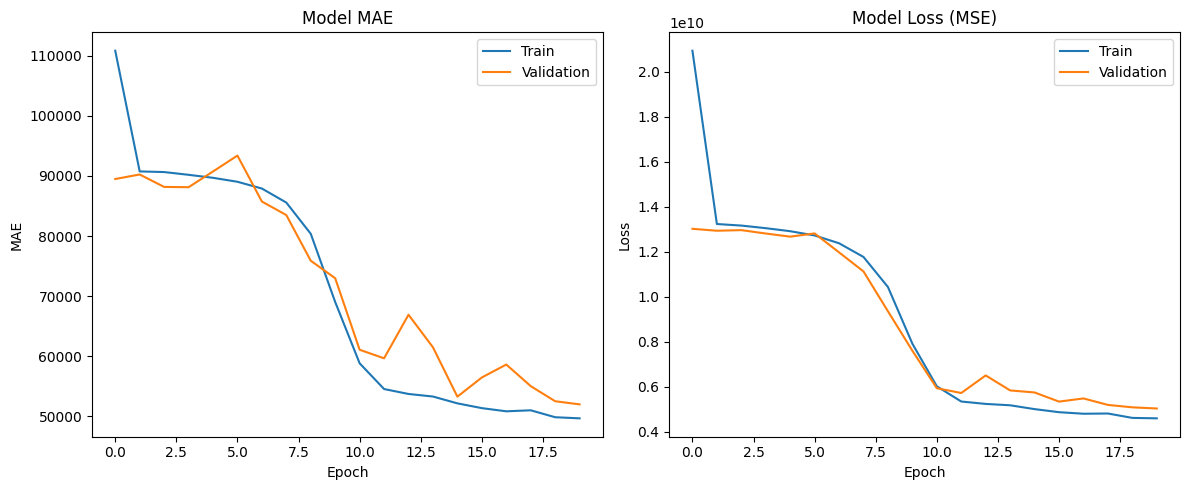

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred = model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nModel Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# You can also visualize the training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation MAE values
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('Model MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

## Final Summary

We successfully implemented a multimodal machine learning pipeline for housing price prediction using both tabular and (dummy) image data. The process involved:

1.  **Loading and preprocessing tabular data** from the California Housing dataset.
2.  **Generating dummy image features** as a placeholder, followed by **CNN feature extraction**.
3.  **Fusing** the image and tabular features into a single dataset.
4.  **Splitting** the data into training and testing sets.
5.  **Training a Keras sequential model** for regression.
6.  **Evaluating the model's performance** on the test set, resulting in:
    *   **Mean Absolute Error (MAE): 51030.04**
    *   **Root Mean Squared Error (RMSE): 71195.73**

